### In this tutorial, we will use ```mne``` to load ```.cnt``` file

- author: Wei Liu
- Date: May 11, 2021
- [BCMI lab, Shanghai Jiao Tong University](http://bcmi.sjtu.edu.cn)

For more information about ```mne```, please go to website: [https://mne.tools/stable/index.html](https://mne.tools/stable/index.html)

In [32]:
import numpy as np
import mne
import sys
sys.path.append("../Preprocessing")
from convertTUHtoBIDS import CHANNELS_TO_KEEP

print(np.__version__)
print(mne.__version__)

1.26.4
1.8.0


In [36]:
# use mne to load the file "6_3_20180802.cnt"
eeg_raw = mne.io.read_raw_cnt('/home/azureuser/mycontainer/SEED-V/SEED-V/EEG_raw/7_1_20180411.cnt')
print(eeg_raw)
print('\n')
print(eeg_raw.info)

/tmp/ipykernel_148415/3912626738.py:2: RuntimeWarning: Could not define the number of bytes automatically. Defaulting to 2.
  eeg_raw = mne.io.read_raw_cnt('/home/azureuser/mycontainer/SEED-V/SEED-V/EEG_raw/7_1_20180411.cnt')


IndexError: index -1 is out of bounds for axis 0 with size 0

In [35]:
print(eeg_raw.annotations)

<Annotations | 0 segments>


In [31]:
# check channel names
ch_names = eeg_raw.ch_names
print(ch_names)
print(len(ch_names))
print('\n')

# drop non-used channels
useless_ch = ['M1', 'M2', 'VEO', 'HEO']
eeg_raw.drop_channels(useless_ch)
new_ch = eeg_raw.ch_names
print(new_ch)
print(len(new_ch))
print('\n')

['FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'T8', 'M1', 'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'TP8', 'M2', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6', 'PO8', 'CB1', 'O1', 'OZ', 'O2', 'CB2', 'VEO', 'HEO']
66


['FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'TP8', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6', 'PO8', 'CB1', 'O1', 'OZ', 'O2', 'CB2']
62




In [27]:
channels_to_drop = [ch_name for ch_name in eeg_raw.ch_names if ch_name not in CHANNELS_TO_KEEP]
channels_to_drop.remove('FP1')
channels_to_drop.remove('FP2')
channels_to_drop.remove('FZ')
channels_to_drop.remove('CZ')
channels_to_drop.remove('PZ')
channels_to_drop.remove('C5')
channels_to_drop.remove('C6')
channels_to_drop.remove('P5')
channels_to_drop.remove('P6')

eeg_raw.drop_channels(channels_to_drop)

print(eeg_raw.info)

<Info | 9 non-empty values
 bads: []
 ch_names: FP1, FP2, F7, F3, FZ, F4, F8, C5, C3, CZ, C4, C6, P5, P3, PZ, ...
 chs: 19 EEG
 custom_ref_applied: False
 dig: 69 items (3 Cardinal, 66 EEG)
 highpass: 0.0 Hz
 lowpass: 500.0 Hz
 meas_date: 2018-02-08 11:46:51 UTC
 nchan: 19
 projs: []
 sfreq: 1000.0 Hz
 subject_info: 5 items (dict)
>


In [29]:
to_lowercase = {"FP1": "Fp1",
	"FP2": "Fp2",
	"FZ": "Fz",
	"CZ": "Cz",
	"PZ": "Pz"
}

eeg_raw.rename_channels(to_lowercase)

custom_montage = mne.channels.read_custom_montage('/home/azureuser/mycontainer/SEED-V/SEED-V/channel_62_pos.locs')
eeg_raw.set_montage(custom_montage)

mapping = {
	"C5": "T3",
	"C6": "T4",
	"P5": "T5",
	"P6": "T6",
}
	
eeg_raw.rename_channels(mapping)

<RawCNT | 6_3_20180802.cnt, 19 x 3117520 (3117.5 s), ~33 kB, data not loaded>

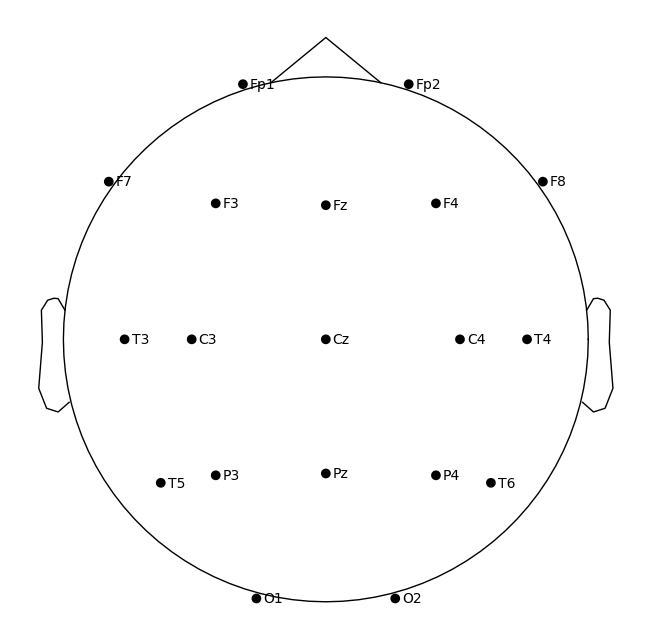

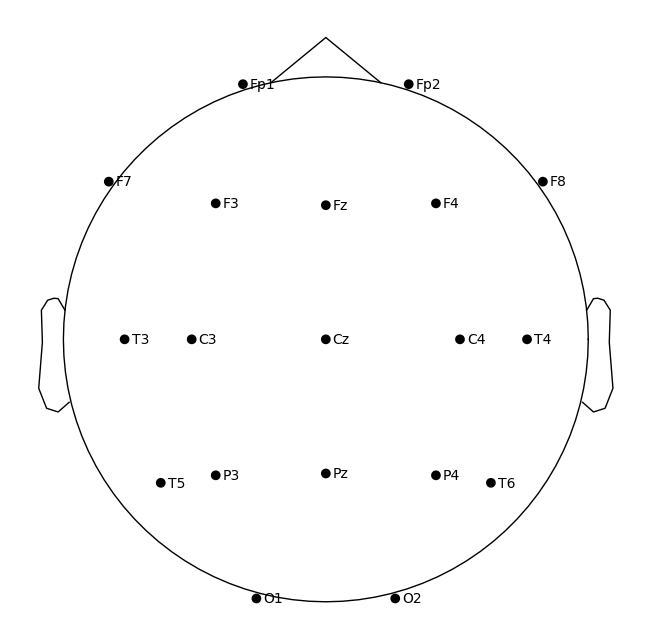

In [30]:
mne.viz.plot_sensors(eeg_raw.info, show_names=True)

In [ ]:
# see raw data wave
eeg_raw.plot()

In [31]:
# get the data matrix
data_matrix = eeg_raw.get_data()
print(data_matrix.shape)

(19, 3117520)


In [32]:
# with file "trial_start_end_timestamp.txt", you can split the data into different trials
start_second = [30, 353, 478, 674, 825, 908, 1200, 1346, 1451, 1711, 2055, 2307, 2457, 2726, 2888]
end_second = [321, 418, 643, 764, 877, 1147, 1284, 1418, 1679, 1996, 2275, 2425, 2664, 2857, 3066]

###########################################################
### Notice: we did not filt the orignal signal here #######
### you may need to filt the data before other process ####
### To filt the signal, please refer to MNE documents #####
###########################################################
start_second = [30, 353, 478, 674, 825, 908, 1200, 1346, 1451, 1711, 2055, 2307, 2457, 2726, 2888]
end_second = [321, 418, 643, 764, 877, 1147, 1284, 1418, 1679, 1996, 2275, 2425, 2664, 2857, 3066]
sample_freq = 1000

data_trial_1 = data_matrix[:, start_second[0]*1000 : end_second[0]*1000]
data_trial_5 = data_matrix[:, start_second[4]*1000 : end_second[4]*1000]
data_trial_15 = data_matrix[:, start_second[14]*1000 : end_second[14]*1000]

print(data_trial_1.shape)
print(data_trial_5.shape)
print(data_trial_15.shape)

(19, 291000)
(19, 52000)
(19, 178000)


With the extract clips, you can extract any features.

In [19]:
import pandas as pd
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
scores = pd.read_csv('/home/azureuser/cloudfiles/code/Users/mchen439/EEG-Foundation-Model/Preprocessing/finetuning/Scores.csv')
scores = scores.iloc[0:48]

In [24]:
print(scores.head())

   Subject  Experiment Index  Trial 0  Trial 1  Trial 2  Trial 3  Trial 4  Trial 5  Trial 6  Trial 7  Trial 8  Trial 9  Trial 10  Trial 11  Tral 12  Trial 13  Trial 14
0      1.0               1.0      2.0      4.0      5.0      2.0      1.0      4.0      5.0      4.0      3.0      2.0       4.0       4.0      5.0       5.0       2.0
1      1.0               2.0      3.0      2.0      5.0      3.0      4.0      3.0      5.0      4.0      4.0      3.0       5.0       2.0      5.0       5.0       2.0
2      1.0               3.0      3.0      2.0      5.0      5.0      2.0      5.0      3.0      4.0      2.0      5.0       5.0       3.0      5.0       4.0       5.0
3      2.0               1.0      3.0      3.0      4.0      4.0      4.0      3.0      5.0      5.0      4.0      5.0       4.0       4.0      4.0       5.0       5.0
4      2.0               2.0      4.0      2.0      5.0      4.0      4.0      4.0      3.0      5.0      5.0      4.0       4.0       5.0      5.0       4.0   

In [21]:
print(scores.tail())

    Name  Experiment Index  Score  Unnamed: 3  Unnamed: 4  Unnamed: 5  Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10  Unnamed: 11  Unnamed: 12  Unnamed: 13  Unnamed: 14  Unnamed: 15  Unnamed: 16
43  15.0               2.0    3.0         2.0         5.0         2.0         4.0         4.0         4.0         5.0          4.0          3.0          4.0          5.0          4.0          4.0          1.0
44  15.0               3.0    2.0         4.0         5.0         4.0         2.0         3.0         3.0         5.0          4.0          5.0          5.0          5.0          5.0          3.0          3.0
45  16.0               1.0    2.0         5.0         4.0         4.0         5.0         3.0         5.0         5.0          4.0          3.0          4.0          4.0          4.0          3.0          3.0
46  16.0               2.0    2.0         3.0         5.0         2.0         2.0         3.0         4.0         5.0          5.0          4.0          4.0        

In [23]:
scores.columns = ["Subject", "Experiment Index", "Trial 0", "Trial 1", "Trial 2", "Trial 3", "Trial 4", "Trial 5", "Trial 6", "Trial 7", "Trial 8", "Trial 9", "Trial 10", "Trial 11", "Tral 12", "Trial 13", "Trial 14"]

In [28]:
scores[scores["Subject"] == 1]["Trial 0"].iloc[0]

2.0

In [43]:
session_start_times = {
	1: [30, 132, 287, 555, 773, 982, 1271, 1628, 1730, 2025, 2227, 2435, 2667, 2932, 3204],
	2: [30, 299, 548, 646, 836, 1000, 1091, 1392, 1657, 1809, 1966, 2186, 2333, 2490, 2741],
	3: [30, 353, 478, 674, 825, 908, 1200, 1346, 1451, 1711, 2055, 2307, 2457, 2726, 2888],
}

session_end_times = {
	1: [102, 228, 524, 742, 920, 1240, 1568, 1697, 1994, 2166, 2401, 2607, 2901, 3172, 3359],
	2: [267, 488, 614, 773, 967, 1059, 1331, 1622, 1777, 1908, 2153, 2302, 2428, 2709, 2817],
	3: [321, 418, 643, 764, 877, 1147, 1284, 1418, 1679, 1996, 2275, 2425, 2664, 2857, 3066],
}
for session in range(1, 4):
	for trial_number, (start_time, end_time) in enumerate(zip(session_start_times[session], session_end_times[session])):
		if start_time + 60 > end_time:
			print(f"Session {session} Trial {trial_number} is less than 60 seconds") 
			print(f"Trial {trial_number} start time: {start_time}, end time: {end_time}")

Session 2 Trial 5 is less than 60 seconds
Trial 5 start time: 1000, end time: 1059
Session 3 Trial 4 is less than 60 seconds
Trial 4 start time: 825, end time: 877
